# CIFAR-10 Image Classification: ANN vs CNN

This project builds and compares image classification models on the CIFAR-10 dataset. The goal is to see how the choice of model architecture and the choice of training strategy each affect performance on a real image task.

We work through three models in order:

1. A plain Artificial Neural Network (ANN) as a baseline
2. A Convolutional Neural Network (CNN) that respects image structure
3. The same CNN trained with data augmentation to test a training strategy

Along the way we look at accuracy, loss curves, generalization, and where each model tends to make mistakes.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

## Setup and how to run

This notebook is written to run on Google Colab with a GPU runtime.

Please note that before running, open Runtime, then Change runtime type, and select a GPU. Then use Runtime, Run all. On a GPU the full notebook finishes in a few minutes. On CPU it still runs, but training takes noticeably longer.

The cell below imports the libraries and fixes the random seeds so that the results stay reasonably repeatable between runs.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Fix seeds so runs stay repeatable
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU available: True


Kindly note that if the line above shows GPU available as True, the models train quickly. If it shows False, everything still works, it just takes longer.

## Load the dataset

Keras ships CIFAR-10 as a built in dataset, so we can pull it directly from there.
Kindly note that the first run downloads it once and caches it for later.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3794s 22us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


As per our observation we infer that the training set holds 50,000 images shaped as 32 by 32 with 3 color channels, and the test set holds 10,000. The labels come as a column of integers from 0 to 9, where each number maps to a class name in the list above.

## Taking a quick look at the data

Before training anything, it helps to actually see the images and confirm the classes are balanced.

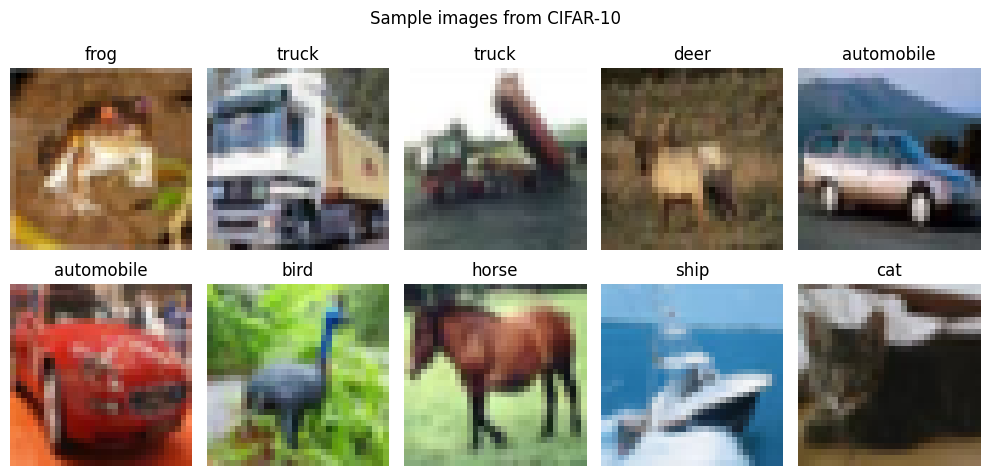

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Sample images from CIFAR-10")
plt.tight_layout()
plt.show()

These images are small and fairly low resolution, so even a person has to look closely at some of them. That difficulty is a big reason a plain ANN struggles on this dataset.

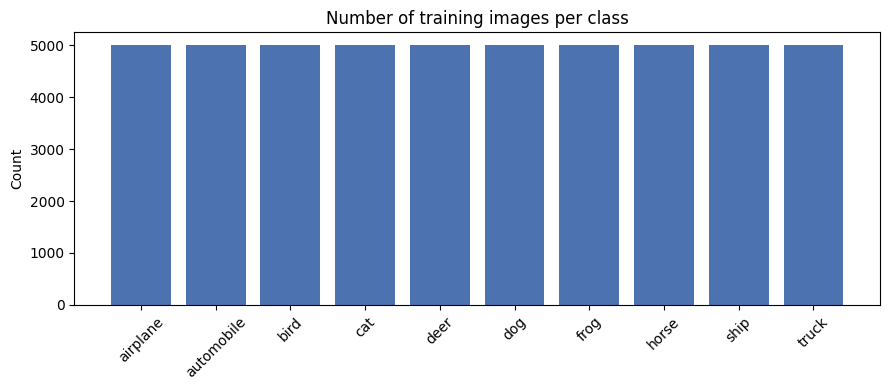

In [4]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(9, 4))
plt.bar([class_names[u] for u in unique], counts, color="#4C72B0")
plt.title("Number of training images per class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Every class has exactly 5,000 training images, so the dataset is perfectly balanced. That means plain accuracy is a fair metric here and we do not need class weighting.

## Preprocessing

Two small steps prepare the data.

First we scale pixel values from the 0 to 255 range down to 0 to 1. Smaller, consistent inputs make the optimizer behave more smoothly.

Second, the ANN needs each image as a single flat vector rather than a 32 by 32 by 3 grid, so we reshape the images into vectors of length 3072 for that model only. The CNN keeps the original image shape because it relies on that spatial layout.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Flat vectors for the ANN (32 * 32 * 3 = 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("CNN input shape:", x_train_norm.shape[1:])
print("ANN input shape:", x_train_flat.shape[1:])

CNN input shape: (32, 32, 3)
ANN input shape: (3072,)


The CNN receives 32 by 32 by 3 images, while the ANN receives flat vectors of length 3072. This difference is exactly what the comparison is about.

## Part 1: Artificial Neural Network baseline

The ANN treats an image as one long list of numbers with no idea which pixels sit next to each other. It makes a reasonable baseline and it shows why a model that ignores spatial structure hits a ceiling on image data.

The architecture uses two hidden dense layers with a dropout layer in between to reduce overfitting, followed by a softmax output over the ten classes.

In [6]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Notice the parameter count from the summary. Most of the weights sit in that first dense layer, because every one of the 3072 inputs connects to all 512 neurons. That is a lot of parameters spent with no awareness of image structure.

In [7]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=25,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2670 - loss: 2.0033 - val_accuracy: 0.3220 - val_loss: 1.8766
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3168 - loss: 1.8714 - val_accuracy: 0.3416 - val_loss: 1.8173
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3303 - loss: 1.8289 - val_accuracy: 0.3652 - val_loss: 1.7719
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3427 - loss: 1.7986 - val_accuracy: 0.3714 - val_loss: 1.7529
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3550 - loss: 1.7730 - val_accuracy: 0.3862 - val_loss: 1.7189
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3621 - loss: 1.7536 - val_accuracy: 0.3786 - val_loss: 1.7335
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3683 - loss: 1.7331 - val_accuracy: 0.4066 - val_loss: 1.6795
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3729 - loss: 1.7227 - val_accuracy: 0.

Early stopping watches the validation accuracy and halts training once it stops improving for five epochs in a row, then restores the best weights. This keeps the ANN from wasting time or drifting into heavy overfitting. The callback resets its state at the start of every fit, so we can reuse it for the later models too.

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN test accuracy: {ann_test_acc:.4f}")
print(f"ANN test loss: {ann_test_loss:.4f}")

The ANN typically lands somewhere around the high 40s to low 50s in percent accuracy. Better than random guessing, which would be 10 percent, but clearly limited.

In [ ]:
def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history.history['accuracy'], label='train')
    ax[0].plot(history.history['val_accuracy'], label='validation')
    ax[0].set_title(f"{title} accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()

    ax[1].plot(history.history['loss'], label='train')
    ax[1].plot(history.history['val_loss'], label='validation')
    ax[1].set_title(f"{title} loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(ann_history, "ANN")

Watch the gap between the training and validation lines. Training accuracy keeps climbing while validation flattens out, which is the classic sign that the model is starting to memorize rather than generalize. Dropout softens this but cannot fix the deeper problem, which is that the ANN never sees the image as an image.

## Part 2: Convolutional Neural Network

A CNN slides small filters across the image, so it learns local patterns like edges and textures and then combines them into larger shapes deeper in the network. This respects the fact that nearby pixels are related, which is exactly what the ANN ignored.

This model stacks three convolutional blocks. Batch normalization steadies the training, max pooling shrinks the feature maps, and a dropout layer near the end reduces overfitting.

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Interesting detail: this CNN often has fewer parameters than the ANN, yet it performs far better. Convolution filters are shared across the whole image, so the model reuses the same small set of weights everywhere instead of learning a separate weight for every pixel position.

In [ ]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

The same early stopping setup is used here. On a GPU each epoch is quick, and the validation accuracy climbs well past anything the ANN reached.

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN test accuracy: {cnn_test_acc:.4f}")
print(f"CNN test loss: {cnn_test_loss:.4f}")

The CNN usually reaches the low to mid 70s in percent accuracy, a large jump over the ANN. The main thing that changed is that the model now understands spatial structure, which tells you how much that structure matters for images.

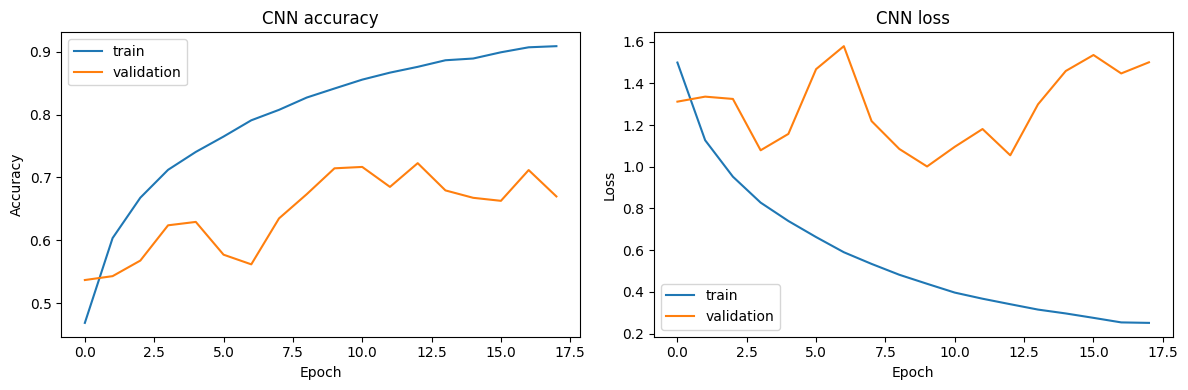

In [13]:
plot_history(cnn_history, "CNN")

The CNN reaches much higher accuracy, though you can still see the training and validation curves separate after a while. That gap is the model overfitting, and it is exactly the problem the next section tries to reduce.

## Part 3: Training strategy, data augmentation

So far the architecture changed. Now we hold the idea of a CNN steady and change the training strategy instead.

Data augmentation makes small random changes to each training image, such as flipping it horizontally, rotating it slightly, or zooming in a little. The model then sees a fresh variation every epoch, which makes it harder to memorize specific images and pushes it to learn features that hold up under change. These transforms only apply during training and switch off automatically at evaluation time.

In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

The architecture matches the earlier CNN on purpose. The only difference is the augmentation block at the front, so any change in results comes from the training strategy rather than a bigger model.

In [ ]:
sample = x_train_norm[0:1]
plt.figure(figsize=(10, 4))
for i in range(8):
    augmented = data_augmentation(sample, training=True)
    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented[0].numpy())
    plt.axis("off")
plt.suptitle("Eight random augmentations of the same image")
plt.tight_layout()
plt.show()

Every tile above starts from the same picture. The flips, small rotations, and zooms give the model a wider, more varied view of each class without needing any extra labeled data.

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=40,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Augmented models usually need more epochs, because each image is harder and the model can no longer take the easy path of memorizing. Early stopping still decides when to finish.

In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN test accuracy: {aug_test_acc:.4f}")
print(f"Augmented CNN test loss: {aug_test_loss:.4f}")

The test accuracy is usually similar to or a little above the plain CNN, but the more important change shows up in the learning curves below.

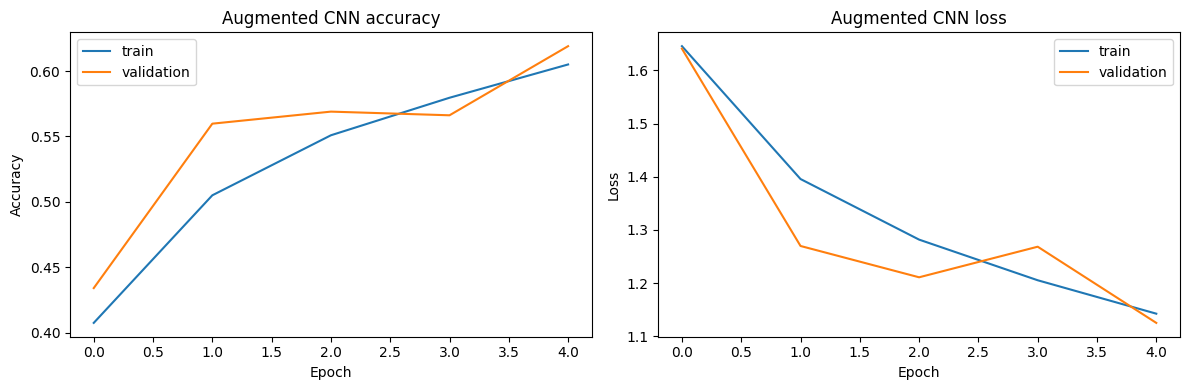

In [18]:
plot_history(aug_history, "Augmented CNN")

The training and validation lines now stay much closer together. The model is no longer racing ahead on the training set, which is the sign that it generalizes better. That smaller gap between what the model learned and how it does on unseen images is the real payoff of augmentation.

## Comparing all three models

With every model trained, we can line them up side by side.

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy across models")
plt.legend()
plt.tight_layout()
plt.show()

The ordering is clear. The ANN sits well below both CNNs, and the two CNNs run far ahead of it. The augmented CNN may start slower but tends to hold a steadier, more trustworthy curve.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss],
    "Parameters": [ann_model.count_params(), cnn_model.count_params(), aug_cnn_model.count_params()]
})
comparison["Test Accuracy"] = (comparison["Test Accuracy"] * 100).round(2)
comparison["Test Loss"] = comparison["Test Loss"].round(4)
comparison

The table makes the tradeoff concrete. The CNNs reach far higher accuracy than the ANN, and they often do it with a similar or smaller number of parameters, because weight sharing in convolution layers is so efficient.

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison["Model"], comparison["Test Accuracy"],
               color=["#C44E52", "#4C72B0", "#55A868"])
plt.ylabel("Test accuracy (%)")
plt.title("Final test accuracy by model")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
             f"{height:.1f}", ha="center")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Seen as bars, the jump from ANN to CNN is the headline result of the whole project.

## Taking a closer look at the best model

Accuracy alone hides where a model struggles. To understand the mistakes, we pick the stronger CNN and look at its predictions class by class.

In [ ]:
# Pick the better of the two CNNs on test accuracy
if aug_test_acc >= cnn_test_acc:
    best_model, best_name = aug_cnn_model, "Augmented CNN"
else:
    best_model, best_name = cnn_model, "CNN"

print("Best model:", best_name)

y_pred_probs = best_model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

Precision and recall break the score down per class. You will usually see clean, distinct classes like ship, truck, and automobile score high, while the animal classes that look alike sit lower.

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title(f"Confusion matrix, {best_name}")
plt.tight_layout()
plt.show()

The diagonal holds the correct predictions, so a bright diagonal is what we want. The off diagonal cells reveal the mix ups. The usual culprits are cat with dog and, to a lesser extent, deer with horse or bird with airplane. These pairs share shapes and backgrounds, so even a good model trips on them at this small resolution.

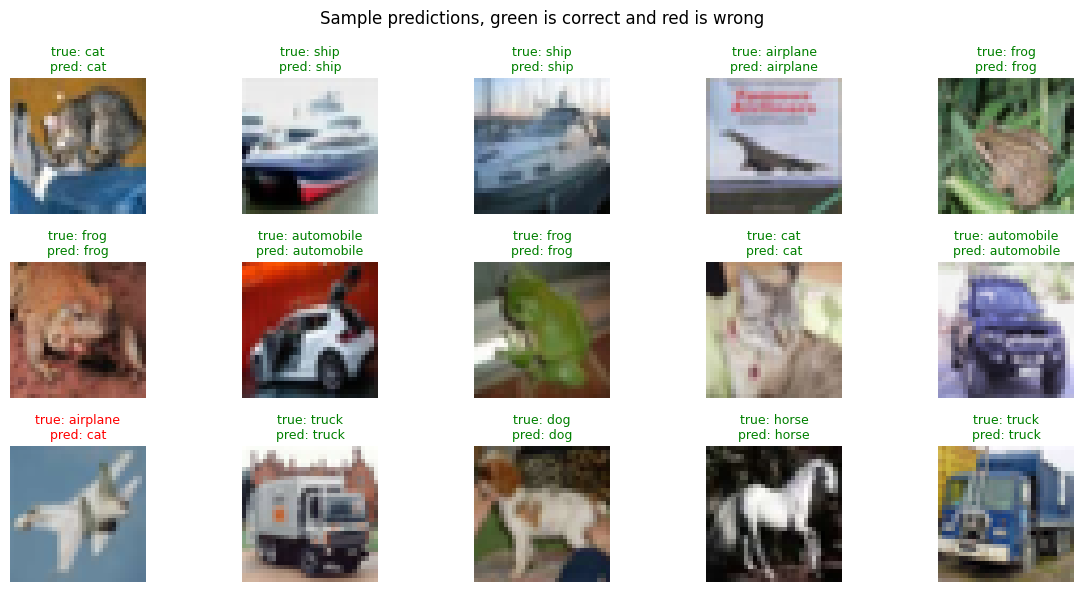

In [24]:
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i])
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    color = "green" if true_label == pred_label else "red"
    plt.title(f"true: {true_label}\npred: {pred_label}", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("Sample predictions, green is correct and red is wrong")
plt.tight_layout()
plt.show()

Green titles are correct and red titles are misses. Looking at the red ones is genuinely useful, since the mistakes often make sense once you notice how similar the images actually are.

## Analysis and discussion

**Architecture matters most.** The single biggest gain came from switching from the ANN to the CNN. The ANN flattens each image and loses every clue about which pixels sit together, so it has to relearn the same pattern separately in every position. The CNN shares small filters across the whole image, which lets it learn an edge or a texture once and detect it anywhere. That is why the CNN roughly matches or beats the ANN while often using fewer parameters.

**Batch normalization and dropout help the CNN train well.** Batch normalization keeps the signal inside each layer in a stable range, which lets training move faster and more smoothly. Dropout randomly switches off part of the network during training, so the model cannot lean too hard on any single neuron and overfits less.

**Data augmentation improves generalization more than raw accuracy.** Adding flips, rotations, and zooms did not always push the headline accuracy up by a large margin, but it closed the gap between the training and validation curves. A model that scores similarly on data it trained on and data it never saw is more reliable, and that is usually what you want in practice.

**Where the models fail is consistent.** Across every version, the hardest cases are visually similar classes, especially cat against dog. This is a limit of the data as much as the model, since a 32 by 32 image simply does not carry much fine detail.

## Conclusion

This project compared two architectures and a training strategy on CIFAR-10.

- The ANN works as a baseline but hits a ceiling because it ignores image structure.
- The CNN gives a large, clear improvement by learning spatial features, and it does so efficiently through weight sharing.
- Data augmentation, applied on top of the CNN, mainly buys better generalization and a smaller gap between training and test behavior.

Put simply, choosing the right architecture gave the biggest single jump, and a sensible training strategy made the result steadier and more dependable. Both choices matter, and together they turn a weak baseline into a solid image classifier.

## Ideas to take this further

A few natural extensions if you want to push the accuracy higher:

- Train for more epochs with a learning rate schedule that lowers the rate over time.
- Add a fourth convolutional block or try a small residual style connection.
- Combine augmentation with a stronger optimizer setup and compare again.
- Try transfer learning from a network already trained on a larger dataset.